# Spam or Not Spam? A Neural Network Lab
**A hands-on companion to the neural network slides · 75–90 minutes**

Build understanding one neuron at a time, then train the same **4 → 3 → 2 → 1** network shown in the slides.

**You will learn to:** turn emails into four inputs; explain weights and bias; calculate propagation separately from activation; follow a full prediction; and explain how training changes weights.

**Before you begin:** basic Python variables and lists are helpful. No calculus is required for the core activities. The gradient code is provided as an optional deeper look.

**Colab setup:** upload this `.ipynb` at [Google Colab](https://colab.research.google.com/). Use a standard CPU runtime. Run cells from top to bottom with **Shift+Enter**. No downloads, API keys, Drive mount, or GPU are needed. All data are fictional and included below.

**Teaching rhythm:** predict the result → run the cell → explain what changed. Editable experiments have working defaults, so the whole notebook also runs without filling in blanks.

This is a small teaching model, not a real email security system. Its four features intentionally leave out most language and context.

## 1. Set up the lab · 3 minutes
NumPy handles the numbers, pandas displays tables, and Matplotlib draws charts.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.figsize": (8, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
FEATURES = ["Spam-like words", "Suspicious-link cue", "Aggressive formatting", "Trusted sender"]
print("Ready: four inputs, two hidden layers, one spam probability.")

Ready: four inputs, two hidden layers, one spam probability.


## 2. Turn an email into four numbers · 8 minutes
Keep the **same feature order** for every email:

| Input | A value of 1 means… |
|---|---|
| $x_1$ | A word such as “free”, “won”, “prize”, or “winner” appears |
| $x_2$ | A phrase such as “click here”, “claim now”, or “verify your account” appears |
| $x_3$ | An uppercase word of at least three letters, or “!!!”, appears |
| $x_4$ | Sender belongs to our small trusted list |

A zero means the cue is absent. These are **toy feature rules**: a “suspicious-link cue” is a phrase match, not an inspection of a link. Uppercase acronyms and legitimate uses of “free” can trigger the rules too.

**Predict:** what should the slide's example email become?

In [2]:
TRUSTED_SENDERS = {"teacher@school.test", "manager@work.test", "friend@example.test"}

def extract_features(text, sender):
    words = set(re.findall(r"\b\w+\b", text.lower()))
    spam_words = bool(words & {"free", "won", "prize", "winner"})
    link_cue = any(phrase in text.lower() for phrase in
                   ["click here", "claim now", "verify your account"])
    formatting = bool(re.search(r"\b[A-Z]{3,}\b", text)) or "!!!" in text
    trusted = sender.lower().strip() in TRUSTED_SENDERS
    return np.array([spam_words, link_cue, formatting, trusted], dtype=float)

slide_email = "You WON a FREE iPhone! Congratulations! Click here now to claim your prize."
slide_sender = "special-offer@deals.test"
x = extract_features(slide_email, slide_sender)
display(pd.DataFrame({"feature": FEATURES, "value": x.astype(int)}))
assert np.array_equal(x, [1, 1, 1, 0])

,feature,value
0,Spam-like words,1
1,Suspicious-link cue,1
2,Aggressive formatting,1
3,Trusted sender,0


**Try it:** edit the message and sender below. Can you make only $x_4$ change? Can a legitimate message contain the word “free”?

In [3]:
my_message = "You WON a FREE iPhone! Click here now to claim your prize."
my_sender = "teacher@school.test"  # Change this and rerun.
display(pd.DataFrame({"feature": FEATURES,
                      "value": extract_features(my_message, my_sender).astype(int)}))

,feature,value
0,Spam-like words,1
1,Suspicious-link cue,1
2,Aggressive formatting,1
3,Trusted sender,1


## 3. One neuron: weights, bias, propagation · 12 minutes
A **weight** controls the effect of an input. The **bias** adds an offset.

The propagation function performs just this calculation:

$$z=w_1x_1+w_2x_2+w_3x_3+w_4x_4+b.$$

Multiply each input by its weight, add the products, then add the bias. **Activation is a separate next step.**

We use the slide's first three weights and bias. The fourth weight is chosen as −1 for this lab; it contributes zero to the original example because $x_4=0$.

**Predict before running:** what is $z$?

Weighted sum: 2.6; bias: -0.5; z: 2.1


,feature,input,weight,input × weight
0,Spam-like words,1.0,1.5,1.5
1,Suspicious-link cue,1.0,0.3,0.3
2,Aggressive formatting,1.0,0.8,0.8
3,Trusted sender,0.0,-1.0,-0.0


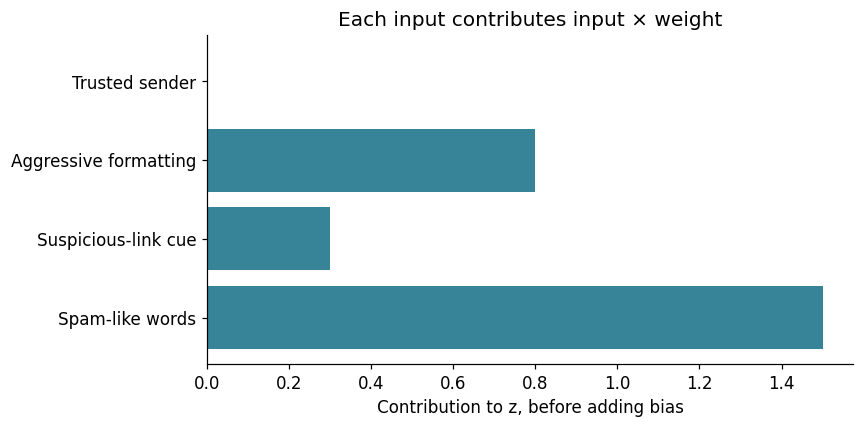

In [4]:
x = np.array([1., 1., 1., 0.])
w = np.array([1.5, 0.3, 0.8, -1.0])
b = -0.5
contributions = x * w
z = contributions.sum() + b
display(pd.DataFrame({"feature": FEATURES, "input": x,
                      "weight": w, "input × weight": contributions}))
print(f"Weighted sum: {contributions.sum():.1f}; bias: {b:.1f}; z: {z:.1f}")
assert np.isclose(z, 2.1)

plt.barh(FEATURES, contributions, color=["#378498"]*3 + ["#aa7550"])
plt.axvline(0, color="gray", linewidth=1)
plt.xlabel("Contribution to z, before adding bias")
plt.title("Each input contributes input × weight")
plt.tight_layout()
plt.show()

### Experiment: change one thing at a time
1. Change the trusted-sender input from 0 to 1. Predict $z$.
2. Restore the inputs and set the first weight to 0. What disappears?
3. Restore the weights and increase the bias by 1. What happens to $z$?

For a fixed change in an input, a larger weight magnitude produces a larger change in $z$. A negative weight reverses the direction. Comparing weight sizes as “importance” also requires comparable input scales.

In [5]:
# Working defaults. Edit a value, predict, and rerun.
experiment_x = np.array([1., 1., 1., 0.])
experiment_w = np.array([1.5, 0.3, 0.8, -1.0])
experiment_b = -0.5
experiment_z = experiment_x @ experiment_w + experiment_b
print(f"z = {experiment_z:.2f}")  # @ calculates the dot product here.

z = 2.10


## 4. Activation and bias · 8 minutes
Propagation gives $z$. An activation function transforms it into the neuron's response:

- **ReLU:** $a=\max(0,z)$, used in our hidden layers.
- **Sigmoid:** $p=1/(1+e^{-z})$, used for our binary output.
- **Tanh:** an alternative hidden activation, shown for comparison.

The bias changes $z$ before activation. For $a=\mathrm{ReLU}(x+b)$, changing $b$ moves the point where the output becomes positive.

For the slide neuron: z = 2.1 → ReLU(z) = 2.1


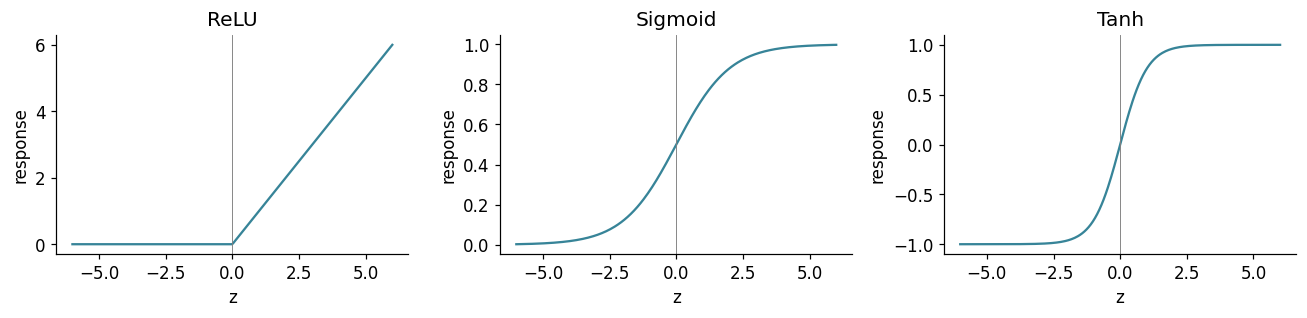

In [6]:
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    z = np.asarray(z, dtype=float)
    # Stable form avoids overflow for very large scores.
    return np.exp(-np.logaddexp(0, -z))

scores = np.linspace(-6, 6, 300)
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, name, values in zip(axes, ["ReLU", "Sigmoid", "Tanh"],
                             [relu(scores), sigmoid(scores), np.tanh(scores)]):
    ax.plot(scores, values, color="#378498")
    ax.axvline(0, color="gray", linewidth=0.6)
    ax.set(title=name, xlabel="z", ylabel="response")
plt.tight_layout()
plt.show()
print(f"For the slide neuron: z = 2.1 → ReLU(z) = {relu(2.1):.1f}")

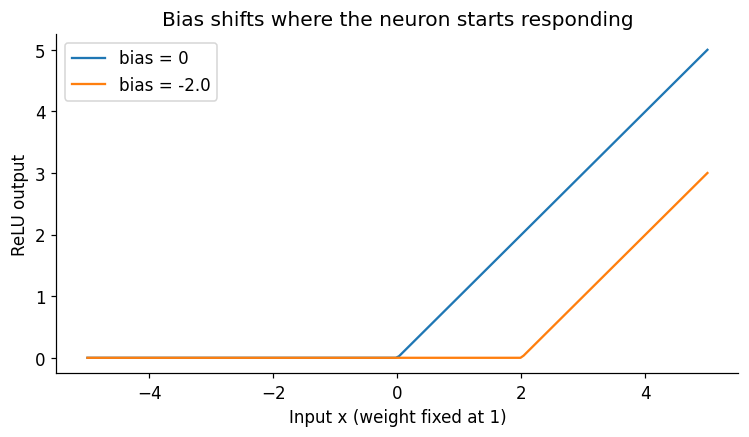

In [7]:
# Try -2, 0, and 2. With weight = 1, the threshold is x = -bias.
bias_to_try = -2.0
input_values = np.linspace(-5, 5, 200)
plt.plot(input_values, relu(input_values), label="bias = 0")
plt.plot(input_values, relu(input_values + bias_to_try), label=f"bias = {bias_to_try}")
plt.xlabel("Input x (weight fixed at 1)")
plt.ylabel("ReLU output")
plt.title("Bias shifts where the neuron starts responding")
plt.legend()
plt.show()

## 5. Follow the slide's 4 → 3 → 2 → 1 network · 10 minutes
Every neuron receives all outputs from the previous layer. This gives **20 weights and 6 biases: 26 trainable parameters**.

The slides specify some illustrative values but not every weight. The following **hand-chosen demonstration parameters** complete a network that reproduces the displayed path:

**[1, 1, 1, 0] → [2.1, 1.4, 0] → [2.6, 0.2] → approximately 0.94.**

These parameters have **not** been trained. We will initialize a separate network for training later.

Rows of each weight matrix are receiving neurons; columns are incoming signals, matching the slide notation. A batch stores one email per row, so the code uses `X @ W.T + b` (the transpose preserves that convention).

In [8]:
demo = {
    "W1": np.array([[1.5, 0.3, 0.8, -1.0],
                    [0.5, 0.5, 0.6, -0.5],
                    [-0.5, 0.2, -0.2, 0.5]]),
    "b1": np.array([-0.5, -0.2, -0.1]),
    "W2": np.array([[1.0, 0.5, 0.2], [0.0, 0.5, 0.3]]),
    "b2": np.array([-0.2, -0.5]),
    "W3": np.array([[1.0, 1.0]]),
    "b3": np.array([-0.05]),
}

def forward(X, params):
    X = np.atleast_2d(X)
    z1 = X @ params["W1"].T + params["b1"]  # Propagation
    a1 = relu(z1)                            # Activation
    z2 = a1 @ params["W2"].T + params["b2"]
    a2 = relu(z2)
    z3 = a2 @ params["W3"].T + params["b3"]
    p = sigmoid(z3)
    return {"X": X, "z1": z1, "a1": a1, "z2": z2,
            "a2": a2, "z3": z3, "p": p}

trace = forward(x, demo)
for name in ["X", "z1", "a1", "z2", "a2", "z3", "p"]:
    print(f"{name:>2}: {trace[name][0]}")
assert np.allclose(trace["a1"], [[2.1, 1.4, 0.]])
assert np.allclose(trace["a2"], [[2.6, 0.2]])
assert np.isclose(trace["z3"].item(), 2.75)
print("Trainable parameters:", sum(v.size for v in demo.values()))

 X: [1. 1. 1. 0.]
z1: [ 2.1  1.4 -0.6]
a1: [2.1 1.4 0. ]
z2: [2.6 0.2]
a2: [2.6 0.2]
z3: [2.75]
 p: [0.94]
Trainable parameters: 26


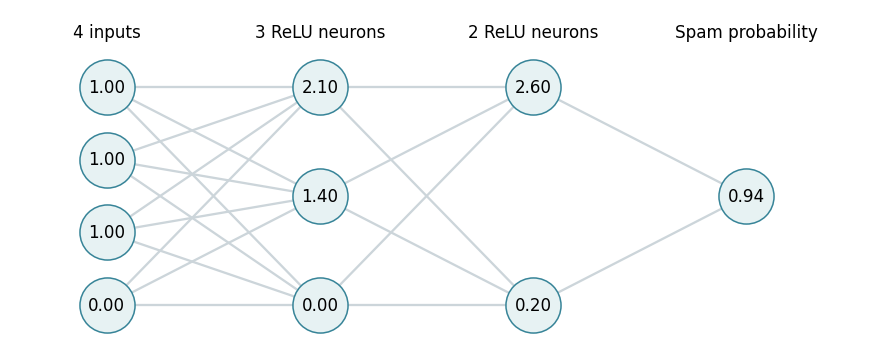

In [9]:
# Visualize the computed signals flowing through the network.
layers = [x, trace["a1"][0], trace["a2"][0], trace["p"][0]]
fig, ax = plt.subplots(figsize=(10, 4))
positions = [np.linspace(1, -1, len(v)) if len(v) > 1 else np.array([0.]) for v in layers]
for layer in range(3):
    for start in positions[layer]:
        for end in positions[layer+1]:
            ax.plot([layer, layer+1], [start, end], color="#ccd5da", zorder=0)
for layer, values in enumerate(layers):
    ax.scatter([layer]*len(values), positions[layer], s=1300, color="#e7f2f3", edgecolor="#378498")
    for y_pos, value in zip(positions[layer], values):
        ax.text(layer, y_pos, f"{value:.2f}", ha="center", va="center")
    ax.text(layer, 1.45, ["4 inputs", "3 ReLU neurons", "2 ReLU neurons", "Spam probability"][layer], ha="center")
ax.set(xlim=(-0.45, 3.55), ylim=(-1.4, 1.7))
ax.axis("off")
plt.show()

### Turn probability into a decision
A threshold is a decision rule, not a learned weight. Raising it flags fewer emails; lowering it flags more. For a fixed set of predictions, raising it cannot increase false positives, but can increase missed spam.

**Try:** compare thresholds 0.5 and 0.95 on the same demonstration probability.

In [10]:
threshold = 0.5
p_demo = trace["p"].item()
print(f"Estimated P(spam): {p_demo:.3f}")
print("Decision:", "Spam" if p_demo >= threshold else "Not Spam")

Estimated P(spam): 0.940
Decision: Spam


## 6. Learn from labeled emails · 15 minutes
Each fictional email below has a manually assigned teaching label: **Spam = 1, Not Spam = 0**. The labels are not computed by the feature rules. There are deliberate exceptions: legitimate mail can say “free” and spam can lack all our cues.

We reserve eight emails as a **test set**. Only training emails update parameters. These are different messages, but some have identical four-feature vectors: the model cannot distinguish emails with the same representation. With just 16 possible binary input combinations and a tiny artificial dataset, test results illustrate evaluation, not real-world performance.

In [11]:
# text, sender, known label. Addresses use reserved example/test domains.
records = [
 ("FREE prize!!! Click here to claim", "offers@promo.test", 1),
 ("You won a prize, claim now", "rewards@promo.test", 1),
 ("WINNER! Verify your account for your prize", "alerts@promo.test", 1),
 ("Free reward available today", "gift@promo.test", 1),
 ("URGENT!!! Verify your account", "security@promo.test", 1),
 ("Click here to claim your bonus", "bonus@promo.test", 1),
 ("You won a free holiday", "travel@promo.test", 1),
 ("FREE cash for you!!!", "cash@promo.test", 1),
 ("Claim now to unlock your prize", "claim@promo.test", 1),
 ("WINNER prize waiting", "lottery@promo.test", 1),
 ("Verify your account to receive cash", "notice@promo.test", 1),
 ("An exclusive investment opportunity awaits", "invest@promo.test", 1),
 ("You WON a FREE phone! Click here", "phone@promo.test", 1),
 ("Prize collection, claim now", "collect@promo.test", 1),
 ("URGENT!!! Claim now", "urgent@promo.test", 1),
 ("Free cash reward today", "reward@promo.test", 1),
 ("Meeting moved to 3 pm", "manager@work.test", 0),
 ("Here is the report", "manager@work.test", 0),
 ("Homework is due tomorrow", "teacher@school.test", 0),
 ("Lunch on Saturday?", "friend@example.test", 0),
 ("Free study resources for class", "teacher@school.test", 0),
 ("Click here for the meeting notes", "manager@work.test", 0),
 ("The team WON the contest!!!", "friend@example.test", 0),
 ("FREE workshop: click here to register", "teacher@school.test", 0),
 ("Your parcel arrives tomorrow", "delivery@shop.test", 0),
 ("Receipt for your recent order", "receipts@shop.test", 0),
 ("Please review the attached agenda", "colleague@work.test", 0),
 ("Free museum entry this weekend", "museum@city.test", 0),
 ("Class starts at nine", "teacher@school.test", 0),
 ("Click here to read our project notes", "manager@work.test", 0),
 ("Your appointment is confirmed", "appointments@clinic.test", 0),
 ("We won the match!!!", "friend@example.test", 0),
]
emails = pd.DataFrame(records, columns=["text", "sender", "label"])
X = np.stack([extract_features(t, s) for t, s, _ in records])
y = emails["label"].to_numpy(dtype=float).reshape(-1, 1)
# Fixed, balanced split: 12 examples of each class for training, 4 each for testing.
test_idx = np.array([12, 13, 14, 15, 28, 29, 30, 31])
train_idx = np.array([i for i in range(len(emails)) if i not in test_idx])
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]
assert set(train_idx).isdisjoint(test_idx)
print(f"Training: {len(train_idx)} emails; testing: {len(test_idx)} emails")
display(emails.iloc[train_idx].head(8))

Training: 24 emails; testing: 8 emails


,text,sender,label
0,FREE prize!!! Click here to claim,offers@promo.test,1
1,"You won a prize, claim now",rewards@promo.test,1
2,WINNER! Verify your account for your prize,alerts@promo.test,1
3,Free reward available today,gift@promo.test,1
4,URGENT!!! Verify your account,security@promo.test,1
5,Click here to claim your bonus,bonus@promo.test,1
6,You won a free holiday,travel@promo.test,1
7,FREE cash for you!!!,cash@promo.test,1


### The training loop
1. **Predict** with current weights and biases.
2. **Measure loss:** binary cross-entropy penalizes incorrect, confident predictions.
3. **Backpropagate:** calculate how each parameter affects the loss.
4. **Update** weights and biases using gradient descent.

$$L=-\frac1N\sum [y\log p+(1-y)\log(1-p)],\qquad
w\leftarrow w-\eta\frac{\partial L}{\partial w}.$$

The learning rate $\eta$ sets the update size. Biases are updated too.

**Instructor cue:** beginners can run the next cell as provided. It exposes the mechanics without requiring a deep-learning library. The matrix gradient details are optional.

Training loss: 0.7345 → 0.1909


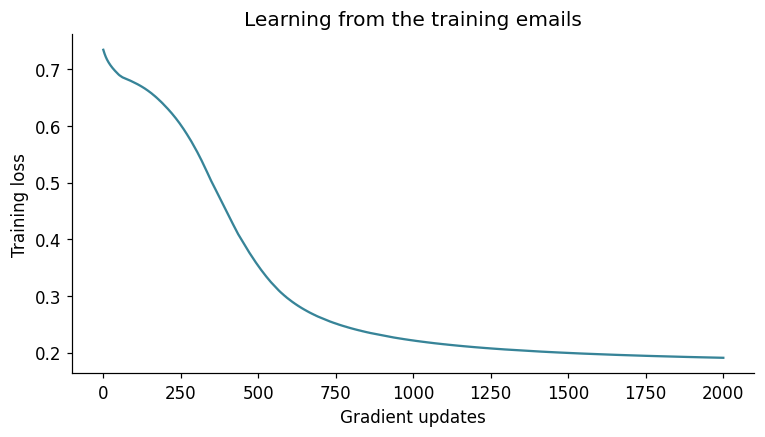

In [12]:
def initialize(seed=42):
    rng = np.random.default_rng(seed)
    params = {}
    for layer, (n_in, n_out) in enumerate([(4, 3), (3, 2), (2, 1)], start=1):
        params[f"W{layer}"] = rng.normal(0, np.sqrt(2/n_in), (n_out, n_in))
        params[f"b{layer}"] = np.full(n_out, 0.1 if layer < 3 else 0.)
    return params

def loss_from_logits(y, z):
    # Numerically stable equivalent of binary cross-entropy after sigmoid.
    return np.mean(np.logaddexp(0, z) - y*z)

def gradients(y, cache, params):
    # Chain rule, from the output layer back toward the inputs.
    dz3 = (cache["p"] - y) / len(y)
    grads = {"W3": dz3.T @ cache["a2"], "b3": dz3.sum(axis=0)}
    dz2 = (dz3 @ params["W3"]) * (cache["z2"] > 0)
    grads.update(W2=dz2.T @ cache["a1"], b2=dz2.sum(axis=0))
    dz1 = (dz2 @ params["W2"]) * (cache["z1"] > 0)
    grads.update(W1=dz1.T @ cache["X"], b1=dz1.sum(axis=0))
    return grads

def train(X_train, y_train, learning_rate=0.05, epochs=2000, seed=42):
    params = initialize(seed)
    history = []
    for epoch in range(epochs):
        cache = forward(X_train, params)
        history.append(loss_from_logits(y_train, cache["z3"]))
        grads = gradients(y_train, cache, params)
        for name in params:
            params[name] -= learning_rate * grads[name]
    history.append(loss_from_logits(y_train, forward(X_train, params)["z3"]))
    return params, np.array(history)

learning_rate = 0.05  # Try a different value after completing the default run.
epochs = 2000
initial_params = initialize(seed=42)
trained_params, history = train(X_train, y_train, learning_rate, epochs)
print(f"Training loss: {history[0]:.4f} → {history[-1]:.4f}")
plt.plot(history, color="#378498")
plt.xlabel("Gradient updates")
plt.ylabel("Training loss")
plt.title("Learning from the training emails")
plt.show()
# Each call to train starts fresh, making experiments comparable.

**Discuss:** initialization affects learning; some random starts can leave ReLU units inactive and predictions near 0.5. We use a fixed seed for a reproducible teaching run. Did the loss decrease? Does low training loss prove the model will work on new emails? Why does the demonstration's 0.94 probability not need to match the trained model?

First-layer biases before: [0.1 0.1 0.1]
First-layer biases after:  [ 0.874 -0.001 -0.006]
Trained probability for slide email: 1.0


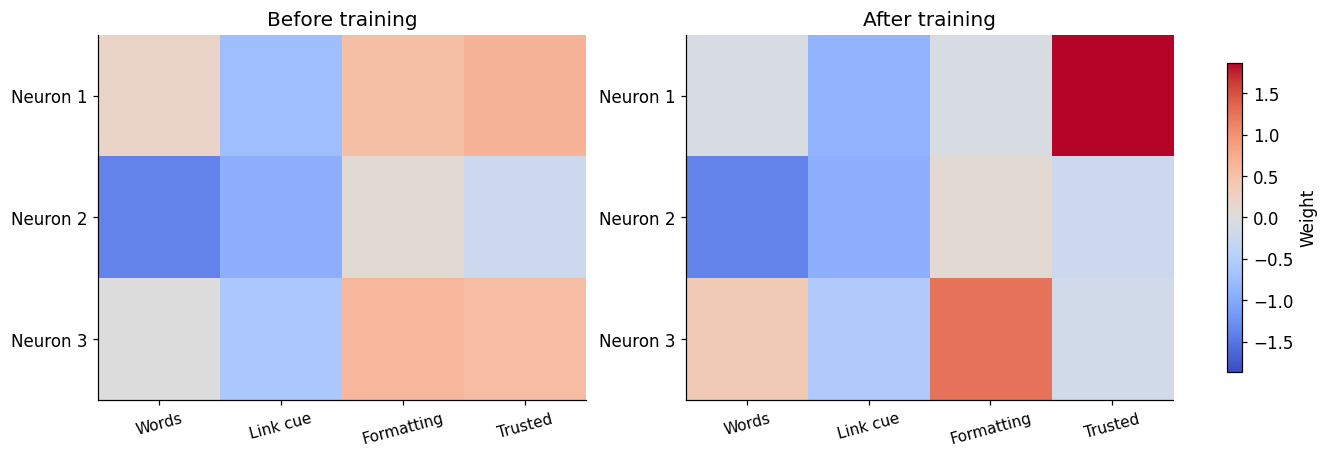

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
limit = max(np.abs(initial_params["W1"]).max(), np.abs(trained_params["W1"]).max())
for ax, params, title in zip(axes, [initial_params, trained_params], ["Before training", "After training"]):
    im = ax.imshow(params["W1"], cmap="coolwarm", vmin=-limit, vmax=limit)
    ax.set_xticks(range(4), ["Words", "Link cue", "Formatting", "Trusted"], rotation=15, fontsize=10)
    ax.set_yticks(range(3), ["Neuron 1", "Neuron 2", "Neuron 3"])
    ax.set_title(title)
fig.colorbar(im, ax=axes, label="Weight", shrink=0.8)
plt.show()
print("First-layer biases before:", initial_params["b1"])
print("First-layer biases after: ", trained_params["b1"])
print("Trained probability for slide email:", round(forward(x, trained_params)["p"].item(), 3))

## 7. Evaluate on unseen emails · 8 minutes
A **false positive** is a legitimate email flagged as spam. A **false negative** is spam that slips through.

We use a fixed threshold of 0.5 for the default evaluation. Try other thresholds to understand the trade-off, but do not choose the “best” threshold from this test set and then claim an unbiased final score. In a larger project, choose settings on a separate validation set.

In [14]:
p_test = forward(X_test, trained_params)["p"].ravel()

def evaluate_threshold(threshold):
    predictions = (p_test >= threshold).astype(int)
    truth = y_test.ravel().astype(int)
    tn = int(np.sum((truth == 0) & (predictions == 0)))
    fp = int(np.sum((truth == 0) & (predictions == 1)))
    fn = int(np.sum((truth == 1) & (predictions == 0)))
    tp = int(np.sum((truth == 1) & (predictions == 1)))
    return {"threshold": threshold, "accuracy": np.mean(predictions == truth),
            "false positives": fp, "missed spam": fn,
            "precision": tp/(tp+fp) if tp+fp else np.nan,
            "recall": tp/(tp+fn) if tp+fn else np.nan}

results = emails.iloc[test_idx][["text", "label"]].copy()
results["P(spam)"] = p_test
results["predicted label"] = (p_test >= 0.5).astype(int)
display(results.round(3))
display(pd.DataFrame([evaluate_threshold(t) for t in [0.2, 0.5, 0.8, 0.95]]).round(3))
print("Precision: fraction of flagged emails that are spam.")
print("Recall: fraction of actual spam that is caught. NaN means a denominator is zero.")

Precision: fraction of flagged emails that are spam.
Recall: fraction of actual spam that is caught. NaN means a denominator is zero.


,text,label,P(spam),predicted label
12,You WON a FREE phone! Click here,1,1.000,1
13,"Prize collection, claim now",1,0.988,1
14,URGENT!!! Claim now,1,0.999,1
15,Free cash reward today,1,0.669,1
28,Class starts at nine,0,0.045,0
29,Click here to read our project notes,0,0.045,0
30,Your appointment is confirmed,0,0.252,0
31,We won the match!!!,0,0.045,0


,threshold,accuracy,false positives,missed spam,precision,recall
0,0.20,0.875,1,0,0.8,1.00
1,0.50,1.000,0,0,1.0,1.00
2,0.80,0.875,0,1,1.0,0.75
3,0.95,0.875,0,1,1.0,0.75


## 8. Try your own fictional email · 5 minutes
Edit the text, sender, and decision threshold. Then explain the result using the four extracted features.

The network only sees those four numbers. It cannot understand an entire message or verify who sent it. Its sigmoid output is an estimated probability; this tiny training exercise does not establish probability calibration.

In [15]:
new_text = "FREE prize!!! Click here to claim now"
new_sender = "offers@promo.test"
new_threshold = 0.5
new_x = extract_features(new_text, new_sender)
new_p = forward(new_x, trained_params)["p"].item()
display(pd.DataFrame({"feature": FEATURES, "value": new_x.astype(int)}))
print(f"Estimated P(spam) = {new_p:.3f}")
print("Decision:", "Spam" if new_p >= new_threshold else "Not Spam")

Estimated P(spam) = 1.000
Decision: Spam


,feature,value
0,Spam-like words,1
1,Suspicious-link cue,1
2,Aggressive formatting,1
3,Trusted sender,0


## 9. Explain it back · 5 minutes
Write one or two sentences for each:

1. What is the difference between a weight and a bias?
2. What does propagation calculate, and how does activation differ?
3. Why are there 26 trainable parameters in this network?
4. Why does a forward pass not change weights?
5. What changes during training? What role does the loss play?
6. Give two messages that could receive identical features but deserve different labels.
7. Why is a high score on eight fictional test emails insufficient evidence for a real spam filter?

**Optional challenges:** compare training learning rates 0.01, 0.05 and 0.5 with a fixed seed; plot their training losses. Make a small validation set before selecting a threshold. Propose a useful fifth feature and identify every part of the network setup that would need changing.

### Suggested answers — open after discussion
<details>
<summary>Reveal explanations</summary>

1. Weights scale individual inputs; bias adds an offset to their combined value.
2. Propagation computes the weighted sum plus bias, z. Activation transforms z into a response.
3. Weights: 4×3 + 3×2 + 2×1 = 20. Biases: 3 + 2 + 1 = 6.
4. It evaluates fixed parameters. Training adds loss calculation, backpropagation, and updates.
5. Weights and biases change. Loss measures prediction error; its gradients guide updates.
6. “Free museum entry this weekend” and “Free cash reward today” from unknown senders both become [1,0,0,0], despite their different teaching labels.
7. The dataset is tiny, fictional, and unrepresentative. Real evaluation needs much more varied, independently held-out email, with attention to false positives and changing spam patterns.

Neuron experiments: trusted sender changed to 1 gives z=1.1; first weight set to zero gives z=0.6; adding 1 to the bias gives z=3.1. These are separate changes from the defaults.

</details>

## References and next steps
- [Google's instructions for uploading a notebook to Colab](https://support.google.com/qwiklabs/answer/16671106?hl=en)
- [NumPy matrix multiplication (`@` / `matmul`)](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html)

This lab follows the presentation's feature order, architecture, and worked neuron. The complete demonstration matrices and fictional training data were constructed for this lab. Richer text representations such as TF-IDF or embeddings are a natural next lesson.